# 02 - Adaptive Thresholds and Static vs Adaptive Comparision

This notebook implements tht proposed adaptive-threshold controller.

The predictor remains offline-trained, but the decision thresholds are updated online using recent KPI feedback.

The goal of this notebook is to compare:
- static thresholds
- adaptive thresholds
under the same traffic sequence

## 1. Imports and load baseline artifacts

This section imports the required libraries and loads the outputs saved from the baseline notebook.

These artifacts include:
- the test-period actual and predicted demand
- the initial fixed thresholds
- the baseline controller time series
- summary tables for the static controller

Using saved artifacts keeps this notebook modular and ensures that the adaptive-threshold experiment starts from exactly the same baseline conditions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pathlib import Path

In [2]:
# Display Setting
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

In [3]:
# Paths
output_dir = Path("../outputs")
fig_dir = output_dir / "figures"
metrics_dir = output_dir / "metrics"
tables_dir = output_dir / "tables"

fig_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

In [4]:
# Load Baseline Artifacts
test_predictions = pd.read_csv(metrics_dir / "test_predictions_for_adaptive.csv", parse_dates=["datetime"])
baseline_thresholds = pd.read_csv(metrics_dir / "baseline_thresholds.csv")
baseline_results = pd.read_csv(metrics_dir / "baseline_results_timeseries.csv", parse_dates=["datetime"])
baseline_summary = pd.read_csv(metrics_dir / "baseline_controller_summary.csv")
baseline_mode_usage = pd.read_csv(metrics_dir / "baseline_mode_usage.csv")

In [5]:
# Inspect Loaded Data
print("test_predictions shape:", test_predictions.shape)
print("baseline_thresholds shape:", baseline_thresholds.shape)
print("baseline_results shape:", baseline_results.shape)
print("baseline_summary shape:", baseline_summary.shape)
print("baseline_mode_usage shape:", baseline_mode_usage.shape)

test_predictions shape: (1293, 3)
baseline_thresholds shape: (1, 4)
baseline_results shape: (1293, 10)
baseline_summary shape: (5, 2)
baseline_mode_usage shape: (3, 2)


In [6]:
# View loaded tables
print("Baseline thresholds:")
display(baseline_thresholds)

print("\nBaseline KPI summary:")
display(baseline_summary)

print("\nBaseline mode usage:")
display(baseline_mode_usage)

Baseline thresholds:


,T_low,T_high,low_percentile,high_percentile
0,345.183152,1624.928177,30,60



Baseline KPI summary:


,metric,value
0,avg_throughput,1201.397499
1,total_drop,408751.948033
2,drop_rate,0.208317
3,avg_energy,101.322506
4,avg_efficiency,10.185520



Baseline mode usage:


,mode,fraction
0,performance,0.396752
1,normal,0.319412
2,energy,0.283836


In [7]:
# Extract initial threshold values
T_low_init = baseline_thresholds.loc[0, "T_low"]
T_high_init = baseline_thresholds.loc[0, "T_high"]

print("Initial T_low:", T_low_init)
print("Initial T_high:", T_high_init)

Initial T_low: 345.18315178692586
Initial T_high: 1624.9281774977514


At this point, the notebook has loaded all of the information needed to reproduce the baseline conditions.

Most importantly:
- the **predictions remain fixed**
- the **initial thresholds match the static controller**
- the **traffic sequence is identical**

This ensures that any difference between the static and adaptive controllers comes from the threshold-update mechanism, not from differences in forecasting or data preparation.

## Section 2 - Restate adaptive hypothesis

**Hypothesis**:
Compared with a fixed-threshold offline controller, and adaptive-threshold controler will achieve a better throughput-energy tradeoff under nonstationary traffic patterns.

The intuition is that fixed thresholds chosen from historical data can become suboptimal when demand changes, while KPI-feedback-based updates can shifts the controller toward more appropriate decisions.

## Section 3 - Define threshold update rule

The adaptive controller updates its thresholds using recent KPI feedback.

- if recent unmet demand is too high, enter performance mode earlier
- if recent energy const is too high while service remains acceptable, favor energy-saving behavior more often

This produces a simple online feedback loop without retraining the predictor.

In [ ]:
# Threshold adaptation settings
UPDATE_INTERVAL = 12        # 12 steps = 2 hours
LOOKBACK_WINDOW = 12        # use recent 2 hours of KPI feedback

DROP_TARGET = 150.0         # target level for recent average drop
ENERGY_TARGET = 100.0       # target level for recent average energy

LOW_STEP = 50.0             # threshold adjustment step for T_low
HIGH_STEP = 50.0            # threshold adjustment step for T_high

MIN_GAP = 100.0             # ensure T_high stays meaningfully above T_low

T_LOW_MIN = 0.0
T_LOW_MAX = 5000.0
T_HIGH_MIN = 0.0
T_HIGH_MAX = 5000.0

In [9]:
# Define threshold clipping helper
def clip_thresholds(t_low, t_high, t_low_min, t_low_max, t_high_min, t_high_max, min_gap):
    t_low = np.clip(t_low, t_low_min, t_low_max)
    t_high = np.clip(t_high, t_high_min, t_high_max)

    # enforce ordering: T_low < T_high
    if t_low >= t_high - min_gap:
        t_low = min(t_low, t_high - min_gap)
        t_high = max(t_high, t_low + min_gap)

    # clip again in case adjustment pushed values out of range
    t_low = np.clip(t_low, t_low_min, t_low_max)
    t_high = np.clip(t_high, t_high_min, t_high_max)

    return t_low, t_high

In [10]:
# Define threshold update rule
def update_thresholds(current_t_low, current_t_high, recent_df):
    """
    Update thresholds using recent KPI feedback.

    Logic:
    - If recent average drop is too high, enter performance mode earlier:
      -> lower T_high
      -> lower T_low slightly to reduce aggressive energy-saving behavior
    - Else if recent energy is too high while drop is acceptable,
      favor energy-saving / less aggressive performance behavior:
      -> raise T_high
      -> raise T_low slightly
    """

    avg_drop = recent_df["drop"].mean()
    avg_energy = recent_df["energy"].mean()

    new_t_low = current_t_low
    new_t_high = current_t_high

    if avg_drop > DROP_TARGET:
        # too much unmet demand -> shift toward performance sooner
        new_t_high -= HIGH_STEP
        new_t_low -= LOW_STEP

    elif avg_energy > ENERGY_TARGET and avg_drop <= DROP_TARGET:
        # energy is too high while service is acceptable -> shift toward lower-energy modes
        new_t_high += HIGH_STEP
        new_t_low += LOW_STEP

    new_t_low, new_t_high = clip_thresholds(
        new_t_low,
        new_t_high,
        T_LOW_MIN,
        T_LOW_MAX,
        T_HIGH_MIN,
        T_HIGH_MAX,
        MIN_GAP
    )

    return new_t_low, new_t_high

In [11]:
# Quick check with examples
# Fake examples just to see how the rule behaves
example_good_service_high_energy = pd.DataFrame({
    "drop": [50, 40, 60, 45],
    "energy": [110, 108, 112, 109]
})

example_bad_service = pd.DataFrame({
    "drop": [220, 180, 210, 230],
    "energy": [95, 98, 100, 97]
})

print("Initial thresholds:", T_low_init, T_high_init)

new_low_1, new_high_1 = update_thresholds(T_low_init, T_high_init, example_good_service_high_energy)
print("After high-energy / acceptable-drop case:", new_low_1, new_high_1)

new_low_2, new_high_2 = update_thresholds(T_low_init, T_high_init, example_bad_service)
print("After high-drop case:", new_low_2, new_high_2)

Initial thresholds: 345.18315178692586 1624.9281774977514
After high-energy / acceptable-drop case: 395.18315178692586 1674.9281774977514
After high-drop case: 295.18315178692586 1574.9281774977514


## Section 4 - Run adaptive controller

The adaptive controller uses the same offline prediction as the baseline.

At each step:
1. use the predicted demand
2. choose a mode based on current thresholds
3. compute KPIs
4. periodically update thresholds using resent KPI history

This isolates the effect of threshold adaptation from forecasting changes.

In [12]:
# Exact mode configuration from Notebook 1
MODE_CONFIG_ABS = {
    "energy": {
        "capacity": 1085.4972829581577,
        "energy_cost": 60
    },
    "normal": {
        "capacity": 1447.3297106108769,
        "energy_cost": 90
    },
    "performance": {
        "capacity": 2315.727536977403,
        "energy_cost": 140
    }
}

def compute_kpis(actual_load, mode, mode_config):
    capacity = mode_config[mode]["capacity"]
    energy = mode_config[mode]["energy_cost"]

    throughput = min(actual_load, capacity)
    drop = max(0.0, actual_load - capacity)
    efficiency = throughput / energy

    return {
        "throughput": throughput,
        "drop": drop,
        "energy": energy,
        "efficiency": efficiency
    }

def choose_mode(predicted_load, t_low, t_high):
    if predicted_load < t_low:
        return "energy"
    elif predicted_load > t_high:
        return "performance"
    else:
        return "normal"

In [13]:
current_t_low = T_low_init
current_t_high = T_high_init

adaptive_rows = []

In [15]:
# Main adaptive loop
for i, row in test_predictions.iterrows():
    current_time = row["datetime"]
    actual_load = row["actual_load"]
    predicted_load = row["predicted_load"]

    # 1. Choose mode using current thresholds
    mode = choose_mode(predicted_load, current_t_low, current_t_high)

    # 2. Compute KPI outcomes
    kpis = compute_kpis(actual_load, mode, MODE_CONFIG_ABS)

    # 3. Save current step
    adaptive_rows.append({
        "datetime": current_time,
        "actual_load": actual_load,
        "predicted_load": predicted_load,
        "mode": mode,
        "T_low": current_t_low,
        "T_high": current_t_high,
        "throughput": kpis["throughput"],
        "drop": kpis["drop"],
        "energy": kpis["energy"],
        "efficiency": kpis["efficiency"]
    })

    # 4. Periodically update thresholds using recent KPI history
    if (i + 1) % UPDATE_INTERVAL == 0 and (i + 1) >= LOOKBACK_WINDOW:
        recent_df = pd.DataFrame(adaptive_rows[-LOOKBACK_WINDOW:])
        current_t_low, current_t_high = update_thresholds(
            current_t_low,
            current_t_high,
            recent_df
        )

In [16]:
# Conver results to DataFrame
adaptive_results = pd.DataFrame(adaptive_rows)
adaptive_results.head()

,datetime,actual_load,predicted_load,mode,T_low,T_high,throughput,drop,energy,efficiency
0,2013-11-21 23:30:00,447.050104,350.045612,normal,345.183152,1624.928177,447.050104,0.0,90,4.967223
1,2013-11-21 23:40:00,454.750193,405.513370,normal,345.183152,1624.928177,454.750193,0.0,90,5.052780
2,2013-11-21 23:50:00,373.324222,380.491356,normal,345.183152,1624.928177,373.324222,0.0,90,4.148047
3,2013-11-22 00:00:00,598.911032,401.631575,normal,345.183152,1624.928177,598.911032,0.0,90,6.654567
4,2013-11-22 00:10:00,265.223864,531.702938,normal,345.183152,1624.928177,265.223864,0.0,90,2.946932


In [17]:
print("Adaptive results shape:", adaptive_results.shape)
print("Unique modes:", adaptive_results["mode"].unique())
print("Missing values:\n", adaptive_results.isna().sum())

Adaptive results shape: (2586, 10)
Unique modes: <ArrowStringArray>
['normal', 'energy', 'performance']
Length: 3, dtype: str
Missing values:
 datetime          0
actual_load       0
predicted_load    0
mode              0
T_low             0
T_high            0
throughput        0
drop              0
energy            0
efficiency        0
dtype: int64


In [18]:
adaptive_results[["datetime", "T_low", "T_high", "mode", "drop", "energy"]].head(20)

,datetime,T_low,T_high,mode,drop,energy
0,2013-11-21 23:30:00,345.183152,1624.928177,normal,0.0,90
1,2013-11-21 23:40:00,345.183152,1624.928177,normal,0.0,90
2,2013-11-21 23:50:00,345.183152,1624.928177,normal,0.0,90
3,2013-11-22 00:00:00,345.183152,1624.928177,normal,0.0,90
4,2013-11-22 00:10:00,345.183152,1624.928177,normal,0.0,90
5,2013-11-22 00:20:00,345.183152,1624.928177,normal,0.0,90
6,2013-11-22 00:30:00,345.183152,1624.928177,normal,0.0,90
7,2013-11-22 00:40:00,345.183152,1624.928177,energy,0.0,60
8,2013-11-22 00:50:00,345.183152,1624.928177,normal,0.0,90
9,2013-11-22 01:00:00,345.183152,1624.928177,normal,0.0,90


## Section 5 - Visualize threshold evolution

This plot shows how the low and high thresholds move during deployment.

It will help with interpret how the controller reacts to periods of:
- high unmet demand
- excessive evergy usage
- changing traffic conditions

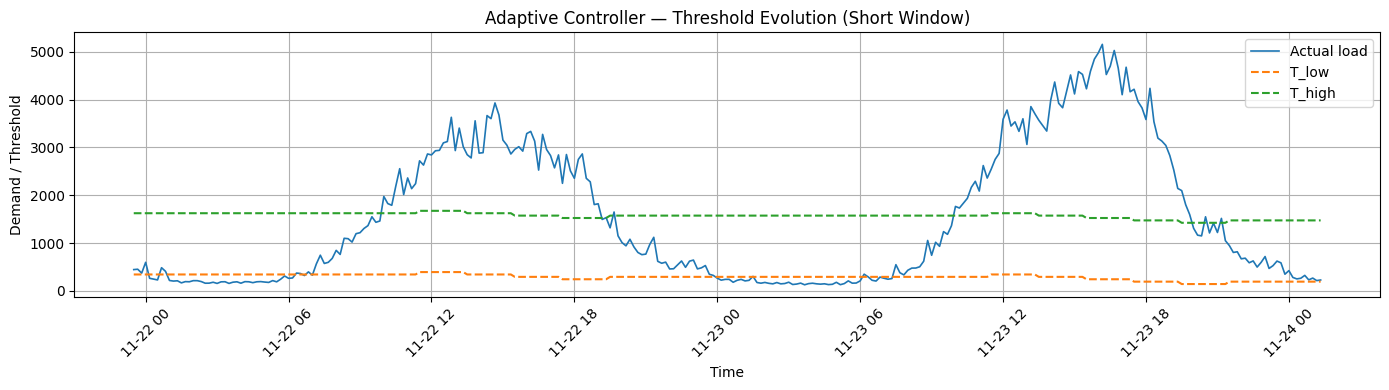

In [19]:
# Plot thresholds over a short window
plot_n = 300
plot_df = adaptive_results.iloc[:plot_n].copy()

plt.figure(figsize=(14, 4))
plt.plot(plot_df["datetime"], plot_df["actual_load"], label="Actual load", linewidth=1.2)
plt.plot(plot_df["datetime"], plot_df["T_low"], label="T_low", linestyle="--", linewidth=1.5)
plt.plot(plot_df["datetime"], plot_df["T_high"], label="T_high", linestyle="--", linewidth=1.5)

plt.title("Adaptive Controller — Threshold Evolution (Short Window)")
plt.xlabel("Time")
plt.ylabel("Demand / Threshold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

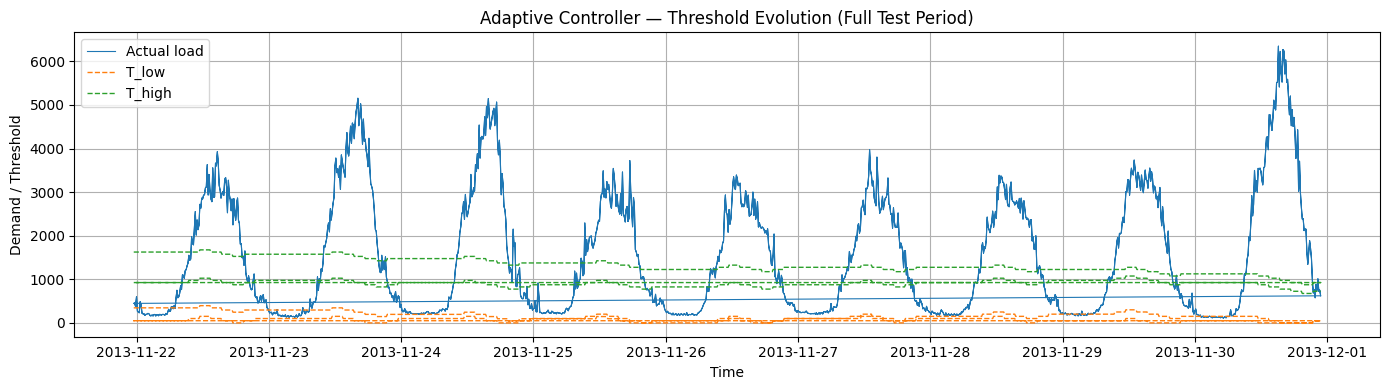

In [20]:
# Plot thresholds over the full test period
plt.figure(figsize=(14, 4))
plt.plot(adaptive_results["datetime"], adaptive_results["actual_load"], label="Actual load", linewidth=0.8)
plt.plot(adaptive_results["datetime"], adaptive_results["T_low"], label="T_low", linestyle="--", linewidth=1.0)
plt.plot(adaptive_results["datetime"], adaptive_results["T_high"], label="T_high", linestyle="--", linewidth=1.0)

plt.title("Adaptive Controller — Threshold Evolution (Full Test Period)")
plt.xlabel("Time")
plt.ylabel("Demand / Threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Show distinct threshold values / update count
print("Number of unique T_low values:", adaptive_results["T_low"].nunique())
print("Number of unique T_high values:", adaptive_results["T_high"].nunique())

print("\nUnique T_low values:")
print(sorted(adaptive_results["T_low"].unique())[:10], "...")

print("\nUnique T_high values:")
print(sorted(adaptive_results["T_high"].unique())[:10], "...")

Number of unique T_low values: 15
Number of unique T_high values: 21

Unique T_low values:
[np.float64(0.0), np.float64(45.18315178692586), np.float64(50.0), np.float64(95.18315178692586), np.float64(100.0), np.float64(145.18315178692586), np.float64(150.0), np.float64(195.18315178692586), np.float64(200.0), np.float64(245.18315178692586)] ...

Unique T_high values:
[np.float64(674.9281774977514), np.float64(724.9281774977514), np.float64(774.9281774977514), np.float64(824.9281774977514), np.float64(874.9281774977514), np.float64(924.9281774977514), np.float64(974.9281774977514), np.float64(1024.9281774977514), np.float64(1074.9281774977514), np.float64(1124.9281774977514)] ...


In [22]:
# Count update events
threshold_changes = (
    (adaptive_results["T_low"].diff().fillna(0) != 0) |
    (adaptive_results["T_high"].diff().fillna(0) != 0)
)

print("Number of threshold update events:", threshold_changes.sum())

Number of threshold update events: 114


## Section 6 - Compare decision: static vs adaptive

The mode sequence produed by the two controllers will be compared.
This reveals whether the adaptive controller:
- enters performance mode earlier
- uses energy-saving mode mroe selectively
- switches more or less frequently

In [23]:
# Prepare static and adaptive comparision tables
static_modes = baseline_results[["datetime", "mode"]].copy().rename(columns={"mode": "static_mode"})
adaptive_modes = adaptive_results[["datetime", "mode"]].copy().rename(columns={"mode": "adaptive_mode"})

mode_compare = static_modes.merge(adaptive_modes, on="datetime", how="inner")
mode_compare.head()

,datetime,static_mode,adaptive_mode
0,2013-11-21 23:30:00,normal,normal
1,2013-11-21 23:30:00,normal,normal
2,2013-11-21 23:40:00,normal,normal
3,2013-11-21 23:40:00,normal,normal
4,2013-11-21 23:50:00,normal,normal


In [24]:
# Map modes to numeric values for plotting
mode_to_num = {
    "energy": 0,
    "normal": 1,
    "performance": 2
}

plot_n = 300
mode_plot_df = mode_compare.iloc[:plot_n].copy()

mode_plot_df["static_mode_num"] = mode_plot_df["static_mode"].map(mode_to_num)
mode_plot_df["adaptive_mode_num"] = mode_plot_df["adaptive_mode"].map(mode_to_num)

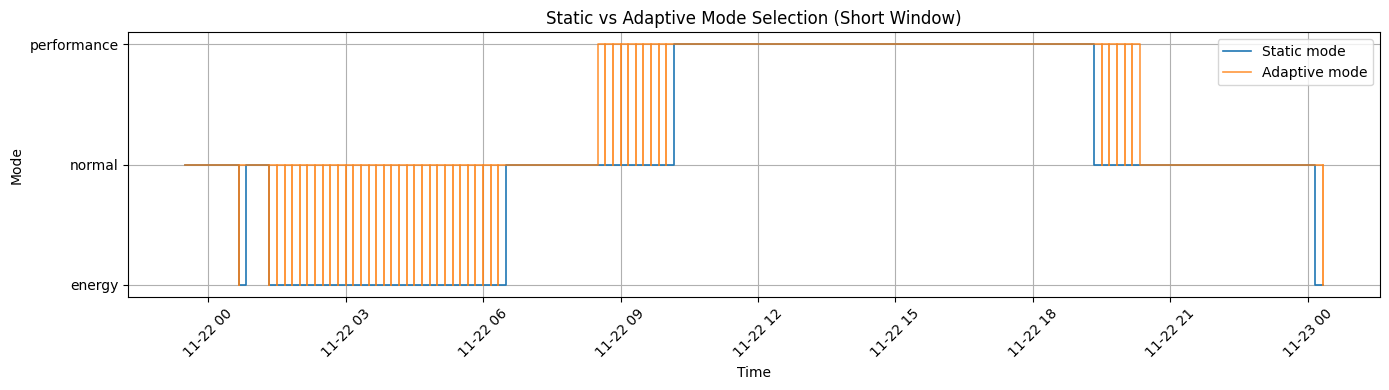

In [25]:
# Plot static vs adaptive mode sequences
plt.figure(figsize=(14, 4))

plt.step(
    mode_plot_df["datetime"],
    mode_plot_df["static_mode_num"],
    where="post",
    label="Static mode",
    linewidth=1.2
)

plt.step(
    mode_plot_df["datetime"],
    mode_plot_df["adaptive_mode_num"],
    where="post",
    label="Adaptive mode",
    linewidth=1.2,
    alpha=0.8
)

plt.yticks([0, 1, 2], ["energy", "normal", "performance"])
plt.title("Static vs Adaptive Mode Selection (Short Window)")
plt.xlabel("Time")
plt.ylabel("Mode")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# Compute mode usage fractions
static_mode_usage = (
    baseline_results["mode"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
)
static_mode_usage.columns = ["mode", "fraction"]
static_mode_usage["controller"] = "static"

adaptive_mode_usage = (
    adaptive_results["mode"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
)
adaptive_mode_usage.columns = ["mode", "fraction"]
adaptive_mode_usage["controller"] = "adaptive"

mode_usage_compare = pd.concat([static_mode_usage, adaptive_mode_usage], ignore_index=True)
mode_usage_compare

,mode,fraction,controller
0,performance,0.396752,static
1,normal,0.319412,static
2,energy,0.283836,static
3,normal,0.490333,adaptive
4,performance,0.481052,adaptive
5,energy,0.028616,adaptive


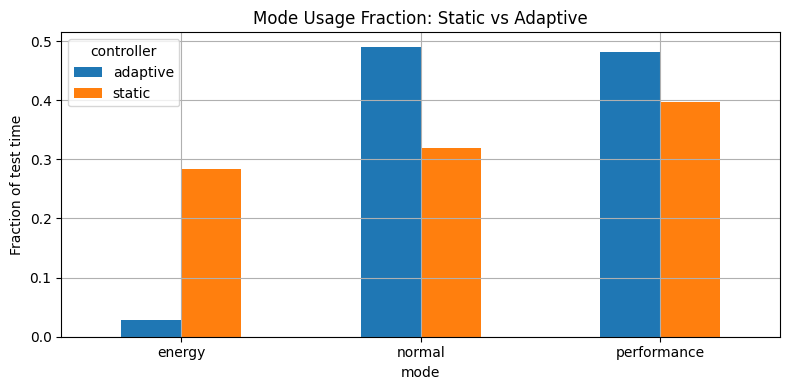

In [27]:
# Plot mode usage comparison
pivot_mode_usage = mode_usage_compare.pivot(index="mode", columns="controller", values="fraction")

pivot_mode_usage.plot(kind="bar", figsize=(8, 4))
plt.title("Mode Usage Fraction: Static vs Adaptive")
plt.ylabel("Fraction of test time")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# Count how often the controllers disagree
mode_compare["different_mode"] = mode_compare["static_mode"] != mode_compare["adaptive_mode"]

num_different = mode_compare["different_mode"].sum()
frac_different = mode_compare["different_mode"].mean()

print("Number of timestamps with different mode decisions:", num_different)
print("Fraction of timestamps with different mode decisions:", frac_different)

Number of timestamps with different mode decisions: 878
Fraction of timestamps with different mode decisions: 0.3395204949729312


## Section 7 - Compare KPI outcomes
The main comparision focuses on:
- average throughput
- total unmet demand
- average energy consumption
- average energy efficiency
These metrics determine whether the adaptive controller improves the throughput-energy tradeoff.

In [29]:
# Summarize adaptive KPI results
adaptive_summary = pd.DataFrame({
    "metric": [
        "avg_throughput",
        "total_drop",
        "drop_rate",
        "avg_energy",
        "avg_efficiency"
    ],
    "value": [
        adaptive_results["throughput"].mean(),
        adaptive_results["drop"].sum(),
        adaptive_results["drop"].sum() / adaptive_results["actual_load"].sum(),
        adaptive_results["energy"].mean(),
        adaptive_results["efficiency"].mean()
    ]
})

adaptive_summary

,metric,value
0,avg_throughput,1207.607015
1,total_drop,801446.085691
2,drop_rate,0.204226
3,avg_energy,113.194122
4,avg_efficiency,9.508721


In [30]:
# Combine static and adaptive summaries
static_summary_labeled = baseline_summary.copy()
static_summary_labeled["controller"] = "static"

adaptive_summary_labeled = adaptive_summary.copy()
adaptive_summary_labeled["controller"] = "adaptive"

kpi_compare = pd.concat([static_summary_labeled, adaptive_summary_labeled], ignore_index=True)
kpi_compare

,metric,value,controller
0,avg_throughput,1201.397499,static
1,total_drop,408751.948033,static
2,drop_rate,0.208317,static
3,avg_energy,101.322506,static
4,avg_efficiency,10.185520,static
5,avg_throughput,1207.607015,adaptive
6,total_drop,801446.085691,adaptive
7,drop_rate,0.204226,adaptive
8,avg_energy,113.194122,adaptive
9,avg_efficiency,9.508721,adaptive


In [31]:
# Pivot comparison table
kpi_compare_pivot = kpi_compare.pivot(index="metric", columns="controller", values="value")
kpi_compare_pivot

controller,adaptive,static
metric,,
avg_efficiency,9.508721,10.185520
avg_energy,113.194122,101.322506
avg_throughput,1207.607015,1201.397499
drop_rate,0.204226,0.208317
total_drop,801446.085691,408751.948033


In [32]:
# Compute relative change
kpi_compare_pivot["relative_change_adaptive_vs_static"] = (
    (kpi_compare_pivot["adaptive"] - kpi_compare_pivot["static"]) / kpi_compare_pivot["static"]
)

kpi_compare_pivot

controller,adaptive,static,relative_change_adaptive_vs_static
metric,,,
avg_efficiency,9.508721,10.185520,-0.066447
avg_energy,113.194122,101.322506,0.117167
avg_throughput,1207.607015,1201.397499,0.005169
drop_rate,0.204226,0.208317,-0.019642
total_drop,801446.085691,408751.948033,0.960715


In [33]:
# Save comparison tables
adaptive_summary.to_csv(metrics_dir / "adaptive_controller_summary.csv", index=False)
kpi_compare.to_csv(metrics_dir / "static_vs_adaptive_kpi_compare_long.csv", index=False)
kpi_compare_pivot.to_csv(metrics_dir / "static_vs_adaptive_kpi_compare_pivot.csv")

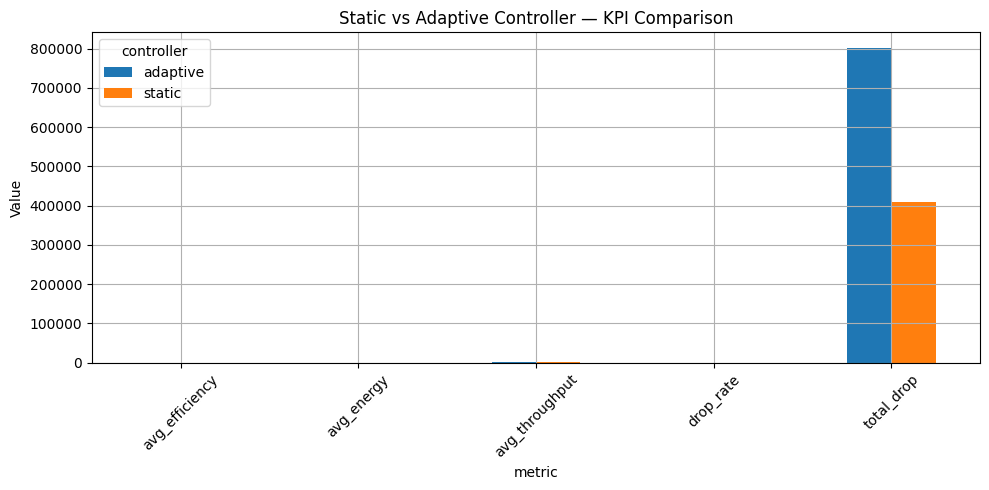

In [34]:
# Bar chart of KPI comparision
kpi_compare_plot = kpi_compare.pivot(index="metric", columns="controller", values="value")

kpi_compare_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Static vs Adaptive Controller — KPI Comparison")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# Compare rolling throughput and energy
rolling_window = 24   # 24 steps = 4 hours

rolling_compare = pd.DataFrame({
    "datetime": adaptive_results["datetime"],
    "static_throughput_roll": baseline_results["throughput"].rolling(rolling_window).mean(),
    "adaptive_throughput_roll": adaptive_results["throughput"].rolling(rolling_window).mean(),
    "static_energy_roll": baseline_results["energy"].rolling(rolling_window).mean(),
    "adaptive_energy_roll": adaptive_results["energy"].rolling(rolling_window).mean(),
})

rolling_compare.head()

,datetime,static_throughput_roll,adaptive_throughput_roll,static_energy_roll,adaptive_energy_roll
0,2013-11-21 23:30:00,NaN,NaN,NaN,NaN
1,2013-11-21 23:40:00,NaN,NaN,NaN,NaN
2,2013-11-21 23:50:00,NaN,NaN,NaN,NaN
3,2013-11-22 00:00:00,NaN,NaN,NaN,NaN
4,2013-11-22 00:10:00,NaN,NaN,NaN,NaN


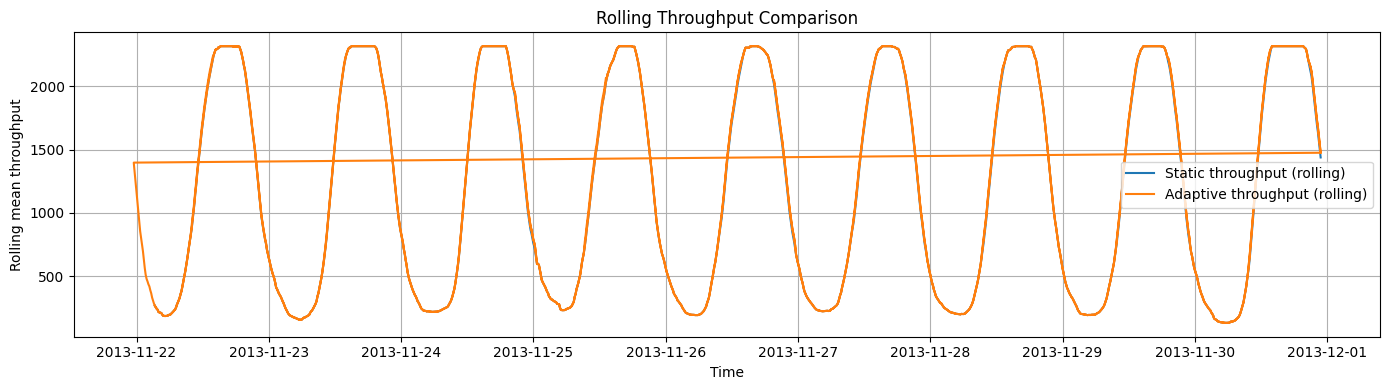

In [36]:
# Rolling throughput plot
plt.figure(figsize=(14, 4))
plt.plot(rolling_compare["datetime"], rolling_compare["static_throughput_roll"], label="Static throughput (rolling)")
plt.plot(rolling_compare["datetime"], rolling_compare["adaptive_throughput_roll"], label="Adaptive throughput (rolling)")

plt.title("Rolling Throughput Comparison")
plt.xlabel("Time")
plt.ylabel("Rolling mean throughput")
plt.legend()
plt.tight_layout()
plt.show()

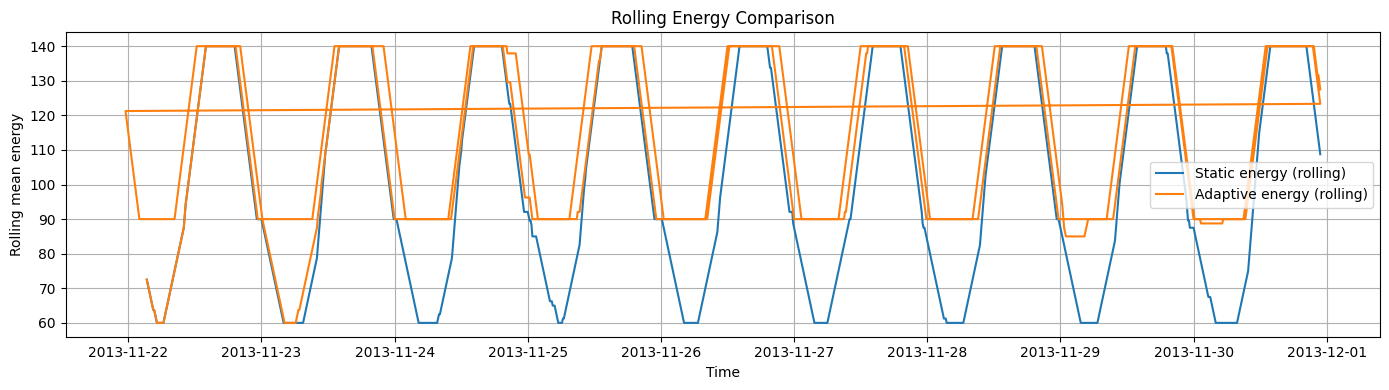

In [37]:
# Rolling energy plot
plt.figure(figsize=(14, 4))
plt.plot(rolling_compare["datetime"], rolling_compare["static_energy_roll"], label="Static energy (rolling)")
plt.plot(rolling_compare["datetime"], rolling_compare["adaptive_energy_roll"], label="Adaptive energy (rolling)")

plt.title("Rolling Energy Comparison")
plt.xlabel("Time")
plt.ylabel("Rolling mean energy")
plt.legend()
plt.tight_layout()
plt.show()

## Section 8 - Analyze switching behavior
Threshold adaptation may improve KPI performance but also increase control instability
To examine this, the following will be compared:
- number of mode switches
- fraction of time spent in each mode
- whether threshold changes appear smooth or overly reactive

In [38]:
# Count mode switches for static and adaptive
def count_mode_switches(mode_series):
    return (mode_series != mode_series.shift(1)).sum() - 1

static_num_switches = count_mode_switches(baseline_results["mode"])
adaptive_num_switches = count_mode_switches(adaptive_results["mode"])

switching_summary = pd.DataFrame({
    "controller": ["static", "adaptive"],
    "num_mode_switches": [static_num_switches, adaptive_num_switches]
})

switching_summary

,controller,num_mode_switches
0,static,56
1,adaptive,58


In [39]:
# Count threshold update events
threshold_update_events = (
    (adaptive_results["T_low"].diff().fillna(0) != 0) |
    (adaptive_results["T_high"].diff().fillna(0) != 0)
)

num_threshold_updates = threshold_update_events.sum()

print("Number of threshold update events:", num_threshold_updates)

Number of threshold update events: 114


In [40]:
# Compute fraction of time with changed thresholds
fraction_threshold_updates = threshold_update_events.mean()

print("Fraction of timestamps with threshold changes:", fraction_threshold_updates)

Fraction of timestamps with threshold changes: 0.04408352668213457


In [42]:
# Summarize adaptive mode usage again for stability context
adaptive_mode_usage = (
    adaptive_results["mode"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
)

adaptive_mode_usage.columns = ["mode", "fraction"]
adaptive_mode_usage["controller"] = "adaptive"

adaptive_mode_usage

,mode,fraction,controller
0,normal,0.490333,adaptive
1,performance,0.481052,adaptive
2,energy,0.028616,adaptive


In [43]:
# Build a compact stability summary table
stability_summary = pd.DataFrame({
    "metric": [
        "static_num_mode_switches",
        "adaptive_num_mode_switches",
        "adaptive_num_threshold_updates",
        "adaptive_fraction_threshold_updates"
    ],
    "value": [
        static_num_switches,
        adaptive_num_switches,
        num_threshold_updates,
        fraction_threshold_updates
    ]
})

stability_summary

,metric,value
0,static_num_mode_switches,56.000000
1,adaptive_num_mode_switches,58.000000
2,adaptive_num_threshold_updates,114.000000
3,adaptive_fraction_threshold_updates,0.044084


In [44]:
# Save stability summary
switching_summary.to_csv(metrics_dir / "mode_switching_summary.csv", index=False)
stability_summary.to_csv(metrics_dir / "adaptive_stability_summary.csv", index=False)

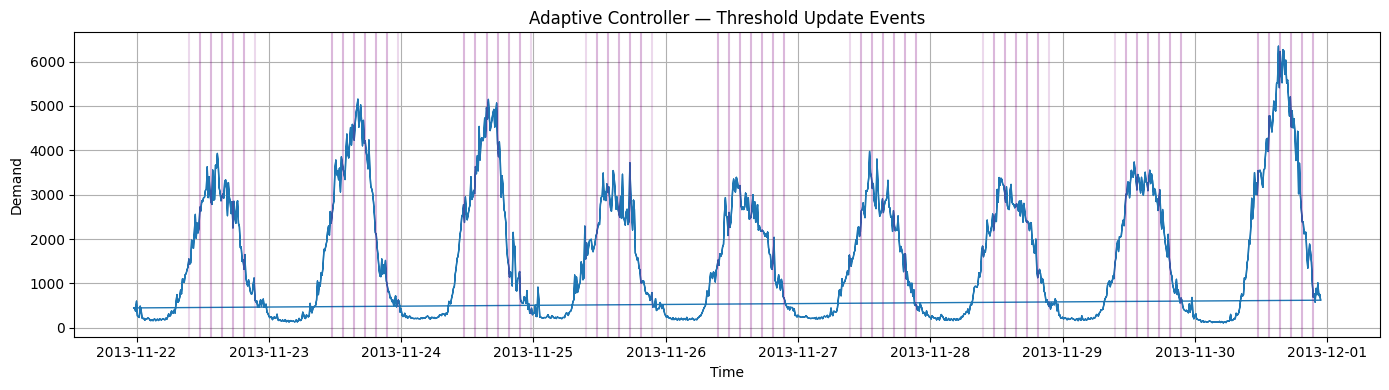

In [45]:
# Plot threshold changes as event markers
update_times = adaptive_results.loc[threshold_update_events, "datetime"]

plt.figure(figsize=(14, 4))
plt.plot(adaptive_results["datetime"], adaptive_results["actual_load"], label="Actual load", linewidth=1.0)

for t in update_times:
    plt.axvline(t, color="purple", alpha=0.15)

plt.title("Adaptive Controller — Threshold Update Events")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

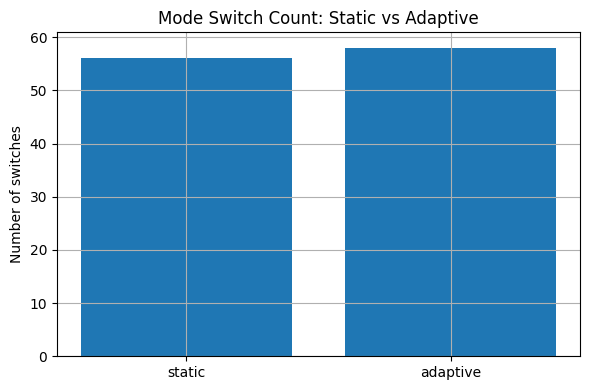

In [46]:
# Compare switching summary visually
plt.figure(figsize=(6, 4))
plt.bar(switching_summary["controller"], switching_summary["num_mode_switches"])
plt.title("Mode Switch Count: Static vs Adaptive")
plt.ylabel("Number of switches")
plt.tight_layout()
plt.show()

## 9. Interpretation

This section interprets the results of the adaptive-threshold experiment in plain language.

The main question is:

> Did online threshold adaptation improve the throughput–energy tradeoff relative to the fixed-threshold baseline?

### 1. Effect on control decisions
The comparison of mode sequences shows whether the adaptive controller actually changed behavior relative to the static controller.

Key things to examine:
- Did the adaptive controller enter performance mode more often during difficult periods?
- Did it reduce unnecessary use of performance mode when energy use was already high?
- Did the adaptive controller meaningfully differ from the static controller, or were the decisions nearly identical?

### 2. Effect on KPI outcomes
The KPI comparison is the core result of the project.

Important questions:
- Did the adaptive controller increase average throughput?
- Did it reduce unmet demand / drop?
- Did those gains require more energy?
- Did energy efficiency improve or worsen?

A useful adaptive controller does not need to dominate every metric simultaneously. A meaningful result can also be:
- better throughput with a moderate energy increase
- better energy efficiency with a small throughput sacrifice
- reduced drop at acceptable energy cost

### 3. Stability of the controller
The stability analysis adds an important qualification to the KPI results.

Even if the adaptive controller improves the average metrics, it may not be desirable if it:
- switches modes too often
- changes thresholds too aggressively
- behaves like a noisy controller rather than a controlled feedback system

So the adaptation mechanism should be judged on both:
- KPI improvement
- behavioral stability

### 4. Overall assessment
At this stage, the adaptive controller should be evaluated as:

- **successful**, if it improves the throughput–energy tradeoff without unstable behavior
- **partially successful**, if it improves one KPI but introduces a reasonable tradeoff elsewhere
- **unsuccessful**, if it fails to improve the tradeoff or behaves too erratically

### 5. Relation to the project hypothesis
The project hypothesis was:

> Compared with a fixed-threshold offline controller, an adaptive-threshold controller will achieve a better throughput–energy tradeoff under changing traffic conditions.

The results of this notebook should now be interpreted directly in relation to that hypothesis.

## Section 10 - Conclusion and next steps

This notebook tested whether KPI-feedback-based threshold adaptation improves a forecast-driven controller relative to a fixed-threshold baseline.

Potential next steps:
- add synthetic drift scenarios
- test multiple grid cells
- replace the predictor with LSTM / transformer / Autoformer
- add online predictor retraining